In [1]:
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
# ==============================
# 2️⃣ CONFIGURATION
# ==============================
BASE_DIR = r"C:\CODING\AI\PROJECTS\HC\Models\FinalDataset\fd\Rotation\Gaussian"  # CHANGE THIS
WORK_DIR =r"C:\CODING\AI\PROJECTS\HC\Models\FinalDataset\fd\Rotation\Gaussian" # Temporary reduced dataset folder

IMG_SIZE = (128, 128)   # Smaller size for speed
BATCH_SIZE = 16
MAX_IMAGES_PER_CLASS = 200  # Limit per class for faster training
EPOCHS = 15

In [3]:
# ==============================
# 4️⃣ DATA GENERATORS
# ==============================
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(WORK_DIR, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    os.path.join(WORK_DIR, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_gen = test_datagen.flow_from_directory(
    os.path.join(WORK_DIR, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 10560 images belonging to 11 classes.
Found 1320 images belonging to 11 classes.
Found 1320 images belonging to 11 classes.


In [4]:
# ==============================
# 5️⃣ CUSTOM VGGNET MODEL
# ==============================
model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(train_gen.num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

c:\CODING\AI\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
# ==============================
# 6️⃣ TRAINING
# ==============================
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

c:\CODING\AI\venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
660/660 ━━━━━━━━━━━━━━━━━━━━ 333s 500ms/step - accuracy: 0.3048 - loss: 1.9494 - val_accuracy: 0.4432 - val_loss: 1.5649
Epoch 2/15
660/660 ━━━━━━━━━━━━━━━━━━━━ 444s 673ms/step - accuracy: 0.4530 - loss: 1.5458 - val_accuracy: 0.5265 - val_loss: 1.3593
Epoch 3/15
660/660 ━━━━━━━━━━━━━━━━━━━━ 1220s 2s/step - accuracy: 0.5469 - loss: 1.2857 - val_accuracy: 0.5932 - val_loss: 1.1563
Epoch 4/15
660/660 ━━━━━━━━━━━━━━━━━━━━ 335s 508ms/step - accuracy: 0.6294 - loss: 1.0557 - val_accuracy: 0.6667 - val_loss: 0.9816
Epoch 5/15
660/660 ━━━━━━━━━━━━━━━━━━━━ 247s 374ms/step - accuracy: 0.7147 - loss: 0.8242 - val_accuracy: 0.6955 - val_loss: 0.9027
Epoch 6/15
660/660 ━━━━━━━━━━━━━━━━━━━━ 285s 432ms/step - accuracy: 0.7829 - loss: 0.6356 - val_accuracy: 0.7061 - val_loss: 0.8874
Epoch 7/15
660/660 ━━━━━━━━━━━━━━━━━━━━ 272s 412ms/step - accuracy: 0.8269 - loss: 0.4989 - val_accuracy: 0.7273 - val_loss: 0.8918
Epoch 8/15
660/660 ━━━━━━━━━━━━━━━━━━━━ 1731s 3s/step - accuracy: 0.8526 - los

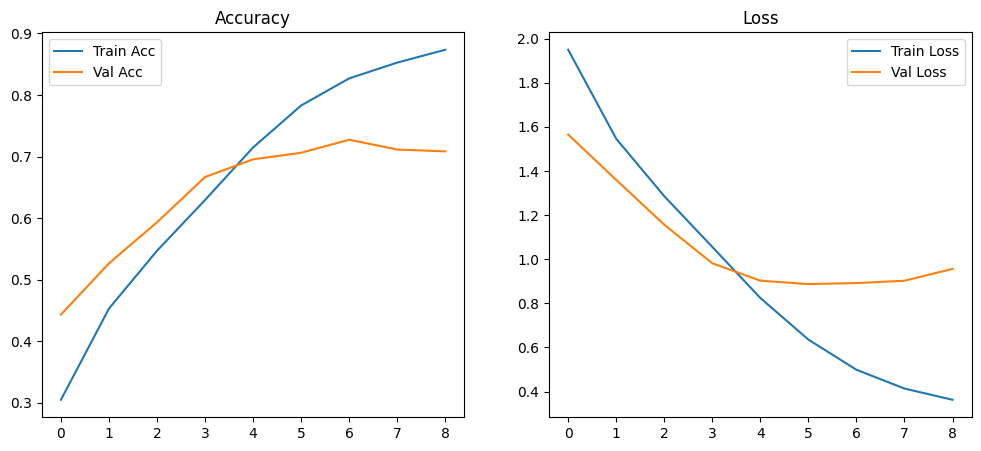

83/83 ━━━━━━━━━━━━━━━━━━━━ 30s 364ms/step - accuracy: 0.6932 - loss: 0.9285
Test Accuracy: 0.6932
83/83 ━━━━━━━━━━━━━━━━━━━━ 18s 216ms/step
                       precision    recall  f1-score      support
Alopecia Areata         0.734848  0.808333  0.769841   120.000000
Contact Dermatitis      0.699248  0.775000  0.735178   120.000000
Folliculitis            0.577778  0.650000  0.611765   120.000000
Head Lice               0.759690  0.816667  0.787149   120.000000
Lichen Planus           0.637097  0.658333  0.647541   120.000000
Male Pattern Baldness   0.845528  0.866667  0.855967   120.000000
Psoriasis               0.561798  0.416667  0.478469   120.000000
Seborrheic Dermatitis   0.610619  0.575000  0.592275   120.000000
Telogen Effluvium       0.631579  0.600000  0.615385   120.000000
Tinea Capitis           0.535088  0.508333  0.521368   120.000000
healthy hair            1.000000  0.950000  0.974359   120.000000
accuracy                0.693182  0.693182  0.693182     0.693182
ma

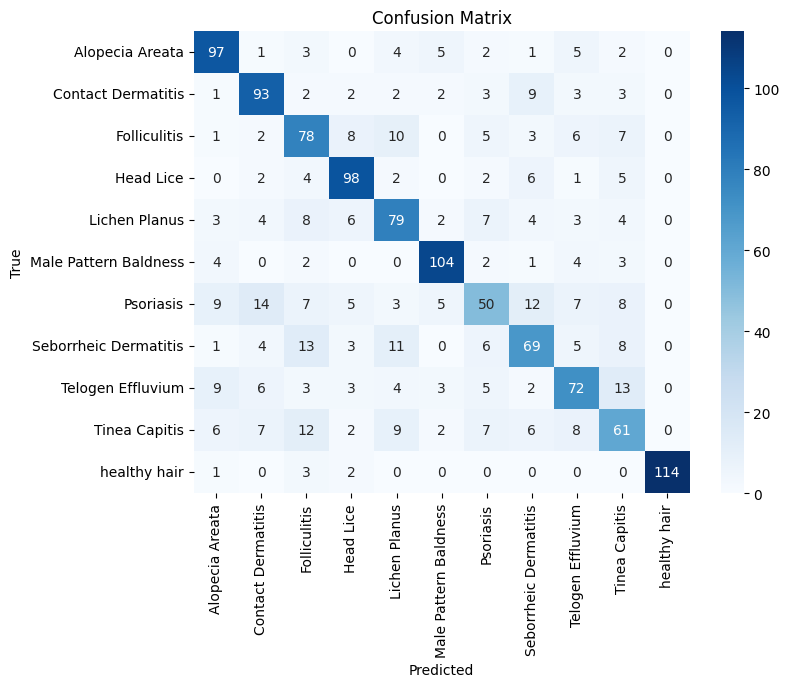

In [6]:
# ==============================
# 7️⃣ EVALUATION
# ==============================
# Accuracy/Loss Graphs
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss")
plt.legend()
plt.show()

# Test evaluation
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc:.4f}")

# Predictions
y_pred = np.argmax(model.predict(test_gen), axis=1)
y_true = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

# Classification report
report = classification_report(y_true, y_pred, target_names=class_labels, output_dict=True)
df_report = pd.DataFrame(report).transpose()
print(df_report)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [7]:
# ==============================
# 8️⃣ SAVE MODEL
# ==============================
model.save("vgg_hair_disease_model.h5")